# Detecting AI-Generated Text: Classic Baseline (Week 1)

SEA 820 NLP Final Project. Team: George and Kasra.

This notebook covers the Week 1 "Foundations and Classic Model" deliverable:

1. Load the [AI vs Human Text](https://www.kaggle.com/datasets/shanegerami/ai-vs-human-text) dataset (Kaggle).
2. Data inspection: columns, labels, missing values, duplicates, class balance.
3. Exploratory Data Analysis (EDA): text length, vocabulary, label distribution, sample texts.
4. Preprocessing pipeline for TF-IDF features.
5. Baseline models: TF-IDF with Logistic Regression, compared against Multinomial Naive Bayes and Linear SVM.
6. Model comparison and feature inspection, to set the baseline score the Week 2 Transformer must beat.

Labels: `generated = 0.0` is human-written, `generated = 1.0` is AI-generated.

## 0. Setup

Runs as-is on Google Colab or locally. Only `pandas`, `numpy`, `scikit-learn`, `matplotlib`, and `seaborn` are required, and all of these come pre-installed on Colab.

In [ ]:
import os, re, io, zipfile, urllib.request, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Environment ready.")

Environment ready.


## 1. Load the dataset

The dataset is the public shanegerami/ai-vs-human-text collection, about 487k essays and roughly 1.1 GB uncompressed.

Loading strategy (no Kaggle credentials needed):
1. If the env var `AIHUMAN_CSV` points to a local copy, use it.
2. If `data/AI_Human.csv` exists, use it.
3. If `AI_Human.csv` exists in the working directory, use it.
4. If `../data/AI_Human.csv` exists, use it.
5. Otherwise, download the public Kaggle archive directly and unzip it into `data/`.


In [2]:
DATA_URL = "https://www.kaggle.com/api/v1/datasets/download/shanegerami/ai-vs-human-text"
CSV_NAME = "AI_Human.csv"
DATA_DIR = "data"


def resolve_csv():
    env = os.environ.get("AIHUMAN_CSV")
    if env and os.path.exists(env):
        print("Using local CSV from AIHUMAN_CSV:", env)
        return env

    candidates = [
        os.path.join(DATA_DIR, CSV_NAME),
        CSV_NAME,
        os.path.join("..", DATA_DIR, CSV_NAME),
    ]
    for candidate in candidates:
        if os.path.exists(candidate):
            print("Using existing", candidate)
            return candidate

    print("Downloading dataset (~350 MB zip)...")
    os.makedirs(DATA_DIR, exist_ok=True)
    zpath = os.path.join(DATA_DIR, "ai-vs-human-text.zip")
    urllib.request.urlretrieve(DATA_URL, zpath)
    with zipfile.ZipFile(zpath) as z:
        z.extractall(DATA_DIR)
    csv_path = os.path.join(DATA_DIR, CSV_NAME)
    print("Downloaded and extracted", csv_path)
    return csv_path


CSV_PATH = resolve_csv()
df = pd.read_csv(CSV_PATH)
print("Loaded:", df.shape)


Using existing AI_Human.csv


Loaded: (487235, 2)


## 2. Data inspection

Before any modelling we check the schema, labels, missing values, duplicates, and class balance.

In [3]:
print("Shape:", df.shape)
print("\nColumns & dtypes:")
print(df.dtypes)
print("\nFirst rows:")
df.head(3)

Shape: (487235, 2)

Columns & dtypes:
text             str
generated    float64
dtype: object

First rows:


,text,generated
0,Cars. Cars have been around since they became ...,0.0
1,Transportation is a large necessity in most co...,0.0
2,"""America's love affair with it's vehicles seem...",0.0


In [4]:
# Label column: 0.0 = human, 1.0 = AI. Cast to int for convenience.
df["generated"] = df["generated"].astype(int)
df["text"] = df["text"].astype(str)

print("Label distribution (raw counts):")
print(df["generated"].value_counts().rename({0: "human (0)", 1: "ai (1)"}))
print("\nLabel proportions:")
print((df["generated"].value_counts(normalize=True) * 100).round(2).rename({0: "human (0)", 1: "ai (1)"}))

Label distribution (raw counts):
generated
human (0)    305797
ai (1)       181438
Name: count, dtype: int64

Label proportions:
generated
human (0)    62.76
ai (1)       37.24
Name: proportion, dtype: float64


In [5]:
# Missing values, duplicates, and empty texts
print("Missing values per column:")
print(df.isna().sum())

full_dupes  = df.duplicated().sum()
text_dupes  = df["text"].duplicated().sum()
empty_texts = (df["text"].str.strip() == "").sum()
print(f"\nFully-duplicated rows : {full_dupes}")
print(f"Duplicated texts      : {text_dupes}")
print(f"Empty / whitespace    : {empty_texts}")

Missing values per column:
text         0
generated    0
dtype: int64



Fully-duplicated rows : 0
Duplicated texts      : 0
Empty / whitespace    : 4


Inspection findings:

- Two columns only: `text` (the essay) and `generated` (the label).
- No missing values and no duplicate texts, so the corpus is clean.
- A handful of empty or whitespace-only rows exist, and these will be dropped in preprocessing.
- The classes are imbalanced, roughly 63% human and 37% AI. This is worth noting even though the brief calls the set balanced. We therefore report precision, recall, and F1 rather than accuracy alone, and we use stratified splits.

## 3. Exploratory Data Analysis

### 3.1 Class distribution

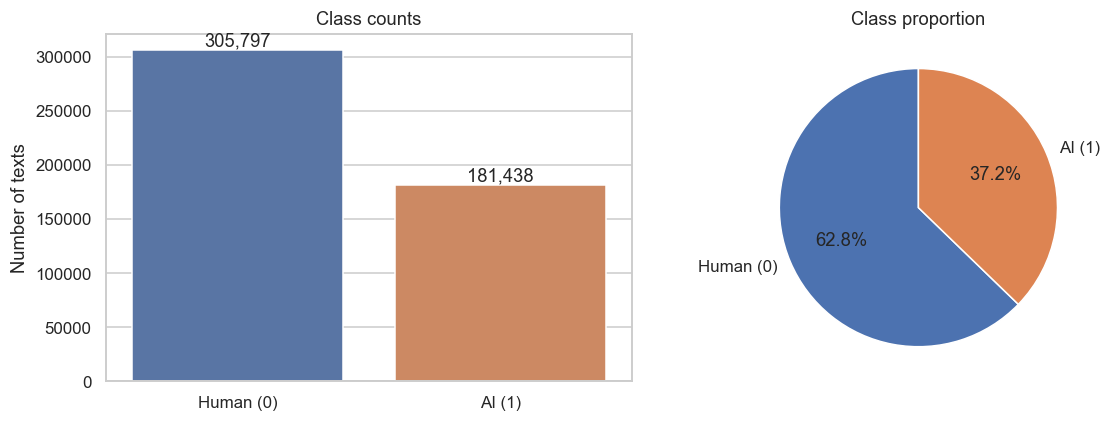

In [6]:
counts = df["generated"].value_counts().sort_index()
labels = ["Human (0)", "AI (1)"]

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(x=labels, y=counts.values, ax=ax[0], palette=["#4C72B0", "#DD8452"])
ax[0].set_title("Class counts"); ax[0].set_ylabel("Number of texts")
for i, v in enumerate(counts.values):
    ax[0].text(i, v, f"{v:,}", ha="center", va="bottom")
ax[1].pie(counts.values, labels=labels, autopct="%1.1f%%",
          colors=["#4C72B0", "#DD8452"], startangle=90)
ax[1].set_title("Class proportion")
plt.tight_layout(); plt.show()

### 3.2 Text length

We measure length in characters and words, and compare the two classes.

In [7]:
df["char_len"]  = df["text"].str.len()
df["word_count"] = df["text"].str.split().map(len)

print("Character length:")
print(df["char_len"].describe().round(1))
print("\nWord count:")
print(df["word_count"].describe().round(1))
print("\nWord count by class:")
print(df.groupby("generated")["word_count"].describe().round(1))

Character length:
count    487235.0
mean       2269.6
std         988.8
min           1.0
25%        1583.0
50%        2102.0
75%        2724.0
max       18322.0
Name: char_len, dtype: float64

Word count:
count    487235.0
mean        393.1
std         168.6
min           0.0
25%         278.0
50%         363.0
75%         471.0
max        1668.0
Name: word_count, dtype: float64

Word count by class:
              count   mean    std   min    25%    50%    75%     max
generated                                                           
0          305797.0  422.0  186.9  14.0  281.0  389.0  520.0  1668.0
1          181438.0  344.4  117.0   0.0  274.0  337.0  403.0  1238.0


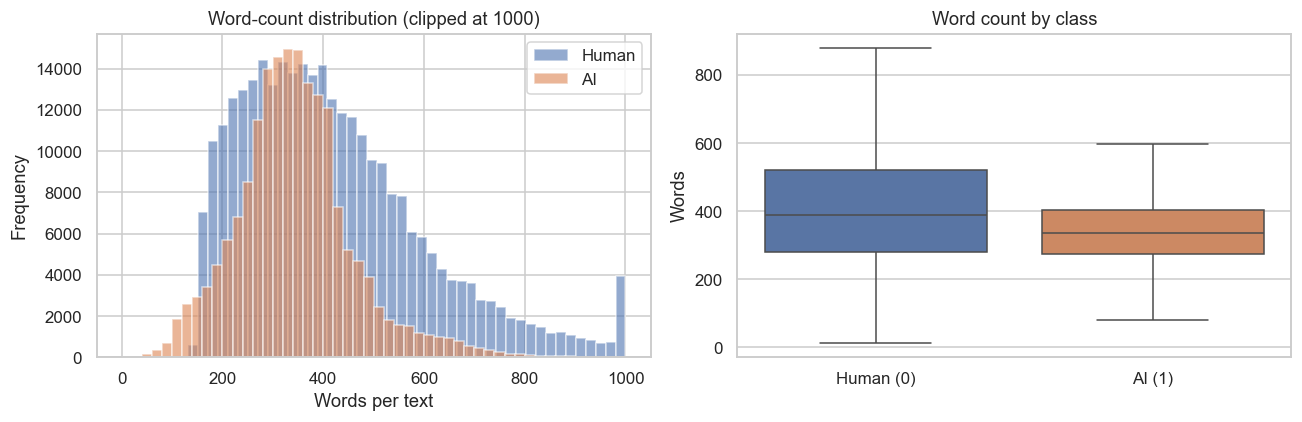

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for lbl, name, col in [(0, "Human", "#4C72B0"), (1, "AI", "#DD8452")]:
    sub = df[df["generated"] == lbl]["word_count"].clip(upper=1000)
    ax[0].hist(sub, bins=50, alpha=0.6, label=name, color=col)
ax[0].set_title("Word-count distribution (clipped at 1000)")
ax[0].set_xlabel("Words per text"); ax[0].set_ylabel("Frequency"); ax[0].legend()

sns.boxplot(data=df, x="generated", y="word_count", ax=ax[1],
            palette=["#4C72B0", "#DD8452"], showfliers=False)
ax[1].set_xticklabels(["Human (0)", "AI (1)"])
ax[1].set_title("Word count by class"); ax[1].set_xlabel(""); ax[1].set_ylabel("Words")
plt.tight_layout(); plt.show()

### 3.3 Vocabulary

We look at the overall vocabulary size and the most distinctive words for each class, using raw term counts with stop-words removed.

In [9]:
from sklearn.feature_extraction.text import CountVectorizer

# Fit on a sample for speed; enough to characterise the vocabulary.
sample = df.sample(n=min(40000, len(df)), random_state=RANDOM_STATE)
cv = CountVectorizer(stop_words="english", min_df=5)
Xc = cv.fit_transform(sample["text"])
print("Vocabulary size (sample, min_df=5, no stopwords):", len(cv.vocabulary_))

vocab = np.array(cv.get_feature_names_out())
def top_words(mask, n=15):
    freqs = np.asarray(Xc[mask.values].sum(axis=0)).ravel()
    idx = freqs.argsort()[::-1][:n]
    return list(zip(vocab[idx], freqs[idx]))

print("\nTop human words:", [w for w, _ in top_words(sample['generated'] == 0)])
print("Top AI words   :", [w for w, _ in top_words(sample['generated'] == 1)])

Vocabulary size (sample, min_df=5, no stopwords): 20986

Top human words: ['people', 'students', 'school', 'car', 'cars', 'like', 'just', 'time', 'help', 'make', 'electoral', 'think', 'student', 'college', 'vote']
Top AI words   : ['students', 'people', 'electoral', 'like', 'college', 'help', 'car', 'time', 'make', 'important', 'states', 'school', 'life', 'cars', 'usage']


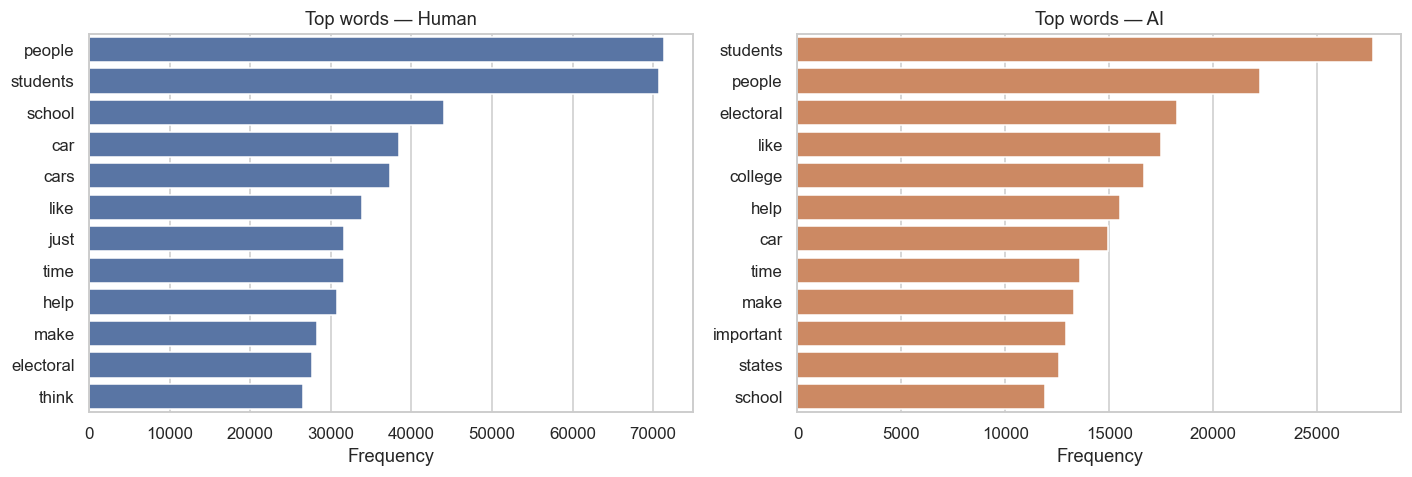

In [10]:
# Visualise the most frequent words per class
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for a, (lbl, name, col) in zip(ax, [(0, "Human", "#4C72B0"), (1, "AI", "#DD8452")]):
    words = top_words(sample["generated"] == lbl, n=12)
    w, f = zip(*words)
    sns.barplot(x=list(f), y=list(w), ax=a, color=col)
    a.set_title(f"Top words - {name}"); a.set_xlabel("Frequency")
plt.tight_layout(); plt.show()

### 3.4 Sample texts

In [11]:
for lbl, name in [(0, "HUMAN"), (1, "AI")]:
    print("=" * 80); print(f"{name} EXAMPLE"); print("=" * 80)
    print(df[df["generated"] == lbl]["text"].iloc[0][:700], "...\n")

HUMAN EXAMPLE


Cars. Cars have been around since they became famous in the 1900s, when Henry Ford created and built the first ModelT. Cars have played a major role in our every day lives since then. But now, people are starting to question if limiting car usage would be a good thing. To me, limiting the use of cars might be a good thing to do.

In like matter of this, article, "In German Suburb, Life Goes On Without Cars," by Elizabeth Rosenthal states, how automobiles are the linchpin of suburbs, where middle class families from either Shanghai or Chicago tend to make their homes. Experts say how this is a huge impediment to current efforts to reduce greenhouse gas emissions from tailpipe. Passenger cars  ...

AI EXAMPLE
This essay will analyze, discuss and prove one reason in favor of keeping the Electoral College in the United States for its presidential elections. One of the reasons to keep the electoral college is that it is better for smaller, more rural states to have more influence as opposed

### EDA summary

- Size and schema: about 487k texts, a single `text` field and a binary `generated` label.
- Balance: roughly 63% human and 37% AI, so the set is imbalanced. Use stratified splits and F1.
- Length: human essays are longer on average (about 420 words) than AI ones (about 340), and length on its own is mildly discriminative. A `max_features` cap and TF-IDF normalization keep the feature space manageable.
- Cleanliness: no missing values, no duplicate texts, a few empty rows to drop.
- Vocabulary: large. Capping to the top 50k n-grams with `min_df` filtering is enough for a strong baseline.

## 4. Preprocessing pipeline (for TF-IDF)

Light, reversible cleaning that preserves signal for a linear model: lower-case, strip URLs, and collapse whitespace. We then drop empty rows and de-duplicate on the cleaned text. This step matters. The raw text has no exact duplicates, but after cleaning some essays collapse to identical strings, so de-duplicating before the split (rather than on the raw text) prevents those near-duplicates from leaking across train and test. Finally we make a stratified 80/20 train/test split.

In [12]:
def clean_text(t: str) -> str:
    t = t.lower()
    t = re.sub(r"http\S+|www\.\S+", " ", t)   # strip URLs
    t = re.sub(r"\s+", " ", t)                # collapse whitespace
    return t.strip()

data = df[df["text"].str.strip() != ""].copy()
data["clean"] = data["text"].map(clean_text)
before = len(data)
# De-duplicate on the CLEANED text so formatting-only variants don't leak across the split.
data = data.drop_duplicates(subset="clean").reset_index(drop=True)
print(f"Rows: {before} -> {len(data)} after dropping {before - len(data)} "
      f"cleaned-text duplicates (leakage guard)")

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    data["clean"], data["generated"],
    test_size=0.2, random_state=RANDOM_STATE, stratify=data["generated"])
print("Train:", X_train.shape[0], "| Test:", X_test.shape[0])

Rows: 487231 -> 464227 after dropping 23004 cleaned-text duplicates (leakage guard)


Train: 371381 | Test: 92846


## 5. TF-IDF feature extraction

Unigrams and bigrams, English stop-words removed, capped at 50k features with `min_df=5` and sublinear TF scaling.

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=50000,
                        min_df=5, sublinear_tf=True, stop_words="english")
Xtr = tfidf.fit_transform(X_train)
Xte = tfidf.transform(X_test)
print("TF-IDF matrix:", Xtr.shape, "| vocabulary:", len(tfidf.vocabulary_))

TF-IDF matrix: (371381, 50000) | vocabulary: 50000


## 6. Baseline models

We train three classic classifiers on the same TF-IDF features and report accuracy, precision, recall, and F1.

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)

results = {}
def evaluate(name, clf):
    clf.fit(Xtr, y_train)
    pred = clf.predict(Xte)
    acc = accuracy_score(y_test, pred)
    pr, rc, f1, _ = precision_recall_fscore_support(y_test, pred, average="binary")
    results[name] = {"accuracy": acc, "precision": pr, "recall": rc, "f1": f1}
    print(f"\n===== {name} =====")
    print(f"accuracy={acc:.4f}  precision={pr:.4f}  recall={rc:.4f}  f1={f1:.4f}")
    print(classification_report(y_test, pred, target_names=["human", "ai"], digits=4))
    return clf, pred

In [15]:
# --- Baseline: TF-IDF + Logistic Regression ---
logreg, logreg_pred = evaluate("Logistic Regression", LogisticRegression(max_iter=1000, C=1.0))


===== Logistic Regression =====
accuracy=0.9947  precision=0.9974  recall=0.9889  f1=0.9931
              precision    recall  f1-score   support

       human     0.9930    0.9983    0.9957     56893
          ai     0.9974    0.9889    0.9931     35953

    accuracy                         0.9947     92846
   macro avg     0.9952    0.9936    0.9944     92846
weighted avg     0.9947    0.9947    0.9947     92846



In [16]:
# --- Comparison model: Multinomial Naive Bayes ---
nb, nb_pred = evaluate("Multinomial NB", MultinomialNB())


===== Multinomial NB =====
accuracy=0.9776  precision=0.9818  recall=0.9599  f1=0.9708
              precision    recall  f1-score   support

       human     0.9750    0.9888    0.9819     56893
          ai     0.9818    0.9599    0.9708     35953

    accuracy                         0.9776     92846
   macro avg     0.9784    0.9744    0.9763     92846
weighted avg     0.9777    0.9776    0.9776     92846



In [17]:
# --- Comparison model: Linear SVM ---
svm, svm_pred = evaluate("Linear SVM", LinearSVC(C=1.0))


===== Linear SVM =====
accuracy=0.9996  precision=0.9997  recall=0.9991  f1=0.9994
              precision    recall  f1-score   support

       human     0.9995    0.9998    0.9996     56893
          ai     0.9997    0.9991    0.9994     35953

    accuracy                         0.9996     92846
   macro avg     0.9996    0.9995    0.9995     92846
weighted avg     0.9996    0.9996    0.9996     92846



### 6.1 Confusion matrix for the best model

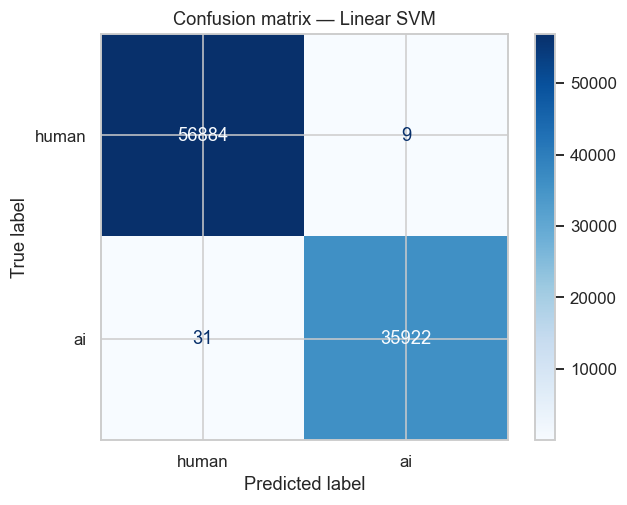

Best model by F1: Linear SVM


In [18]:
best_name = max(results, key=lambda k: results[k]["f1"])
best_pred = {"Logistic Regression": logreg_pred, "Multinomial NB": nb_pred, "Linear SVM": svm_pred}[best_name]
cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["human", "ai"])
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Confusion matrix - {best_name}"); plt.show()
print("Best model by F1:", best_name)

## 7. Model comparison

This table is the baseline the Week 2 fine-tuned Transformer must beat.

                     accuracy  precision  recall      f1
Linear SVM             0.9996     0.9997  0.9991  0.9994
Logistic Regression    0.9947     0.9974  0.9889  0.9931
Multinomial NB         0.9776     0.9818  0.9599  0.9708


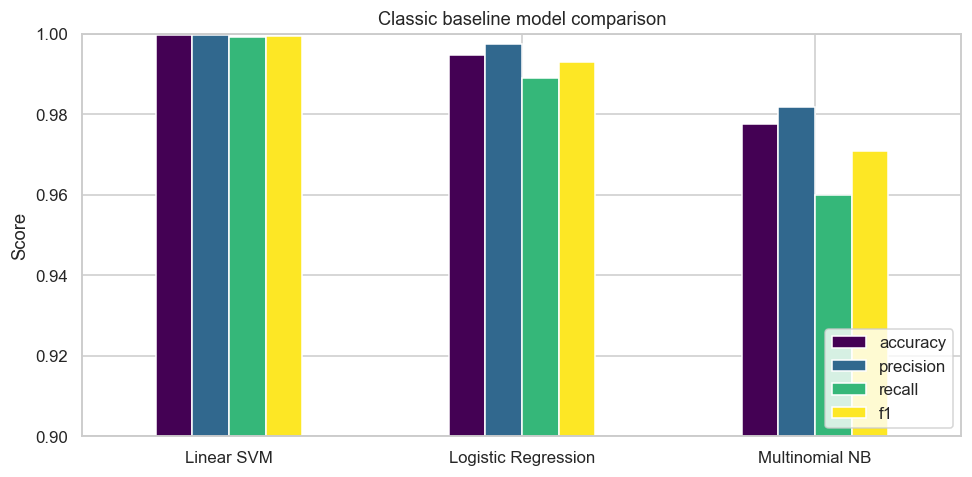

In [19]:
res_df = pd.DataFrame(results).T[["accuracy", "precision", "recall", "f1"]].round(4)
res_df = res_df.sort_values("f1", ascending=False)
print(res_df.to_string())

res_df.plot(kind="bar", figsize=(9, 4.5), ylim=(0.9, 1.0), rot=0,
            colormap="viridis")
plt.title("Classic baseline model comparison")
plt.ylabel("Score"); plt.legend(loc="lower right"); plt.tight_layout(); plt.show()

## 8. What is the model learning?

The strongest indicator words for each class, taken from the Logistic Regression coefficients.

In [20]:
feat = np.array(tfidf.get_feature_names_out())
coefs = logreg.coef_.ravel()
top_ai    = coefs.argsort()[::-1][:20]
top_human = coefs.argsort()[:20]
print("Most AI-indicative tokens:")
print([feat[i] for i in top_ai])
print("\nMost human-indicative tokens:")
print([feat[i] for i in top_human])

Most AI-indicative tokens:
['important', 'essay', 'additionally', 'super', 'conclusion', 'hey', 'potential', 'provide', 'significant', 'essential', 'cool', 'firstly', 'lead', 'totally', 'challenges', 'know people', 'consider', 'risks', 'ensure', 'privacy']

Most human-indicative tokens:
['people', 'going', 'students', 'student', 'school', 'paragraph', 'reason', 'percent', 'said', 'kids', 'voting', 'person', 'doing', 'driving', 'electors', 'humans', 'schools', 'venus', 'probably', 'car']


## 9. Conclusion and next steps

- The classic TF-IDF with Logistic Regression baseline is established, alongside Naive Bayes and Linear SVM for comparison. The best classic model's F1 is the bar for the fine-tuned Transformer in Week 2.
- EDA surfaced a class imbalance (about 63/37) and a length difference between human and AI text. Both are handed to Kasra to set preprocessing constraints.
- Week 2 : load the same split into Hugging Face `datasets`, fine-tune DistilBERT with the `Trainer` API, and compare against this baseline on accuracy, precision, recall, and F1.
- Week 3: error analysis on the best model's misclassifications, plus the ethical discussion.

Reproducibility: re-running this notebook top to bottom downloads the data and regenerates every number and figure above.